In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
from src.utils.io import load_excel

DATA_DIR = PROJECT_ROOT / "data"

val = load_excel(
    DATA_DIR /
    "processed" /
    "processed_elec-prot" /
    "elec-prot_validation.xlsx"
)

In [3]:
train = load_excel(
    DATA_DIR /
    "processed" /
    "processed_elec-prot" /
    "augmented_3.xlsx"
)

In [4]:
features = ["MDR", "PW", "Frequency", "NoP", "TD", "Particle", "Target"]

X_train = train[features]
y_train = train["Endpoint"]

X_val = val[features]
y_val = val["Endpoint"]

In [5]:
# RANDOM FOREST

In [6]:
from src.models.random_forest import train_random_forest

model = train_random_forest(X_train, y_train)

In [7]:
from src.models.evaluation import evaluate_model

evaluate_model(model, X_val, y_val)

{'accuracy': 0.7619047619047619,
 'f1': 0.7619047619047619,
 'confusion_matrix': array([[8, 1],
        [4, 8]]),
 'fpr': array([0.        , 0.        , 0.        , 0.        , 0.22222222,
        0.44444444, 0.44444444, 0.55555556, 0.55555556, 0.77777778,
        0.77777778, 1.        , 1.        ]),
 'tpr': array([0.        , 0.08333333, 0.25      , 0.66666667, 0.66666667,
        0.66666667, 0.75      , 0.75      , 0.83333333, 0.83333333,
        0.91666667, 0.91666667, 1.        ]),
 'roc_auc': 0.7685185185185186}

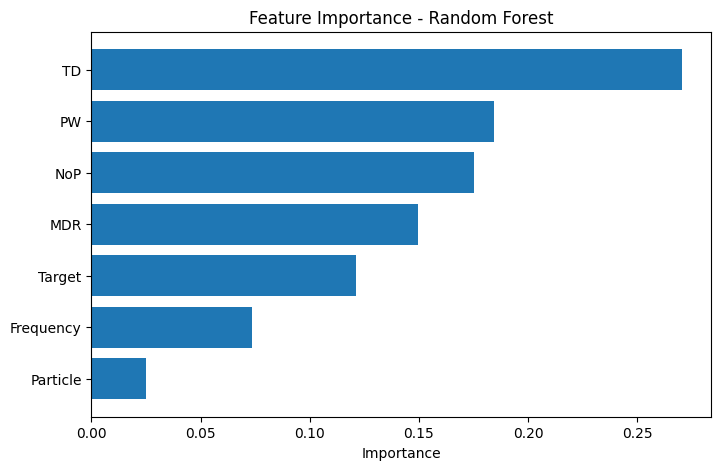

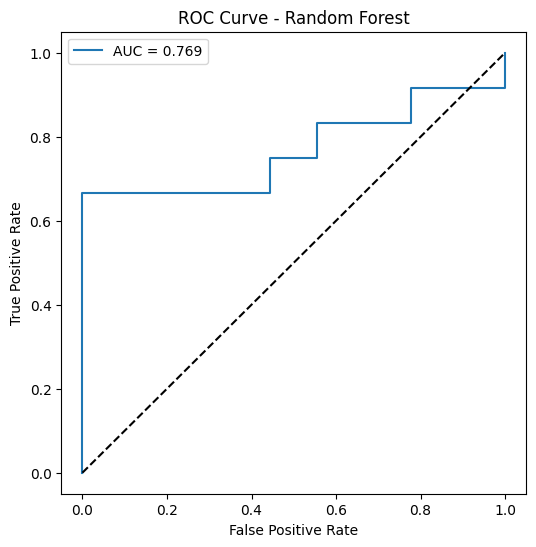

In [8]:
from src.models.evaluation import get_feature_importance
from src.visualization.plots import plot_feature_importance, plot_roc_curve

feature_importance = get_feature_importance(model, features)
plot_feature_importance(feature_importance, "Random Forest")
plot_roc_curve(model, X_val, y_val, "Random Forest")

In [9]:
from src.models.evaluation import cross_validate_model
cross_validate_model(model, X_train, y_train)

{'f1_scores': array([0.94339623, 0.88888889, 0.90196078, 0.94339623, 0.85185185]),
 'accuracy_scores': array([0.94230769, 0.88235294, 0.90196078, 0.94117647, 0.84313725]),
 'f1_mean': np.float64(0.9058987955769311),
 'f1_std': np.float64(0.034750630564617364),
 'acc_mean': np.float64(0.9021870286576169),
 'acc_std': np.float64(0.037443723711967074)}

In [10]:
# XGBOOST

In [11]:
from src.models.xgboost import train_xgb

model_xgb = train_xgb(X_train, y_train)

In [12]:
from src.models.evaluation import evaluate_model

evaluate_model(model_xgb, X_val, y_val)

{'accuracy': 0.7619047619047619,
 'f1': 0.7619047619047619,
 'confusion_matrix': array([[8, 1],
        [4, 8]]),
 'fpr': array([0.        , 0.        , 0.        , 0.11111111, 0.11111111,
        0.33333333, 0.55555556, 0.55555556, 0.77777778, 0.77777778,
        1.        , 1.        ]),
 'tpr': array([0.        , 0.08333333, 0.58333333, 0.58333333, 0.66666667,
        0.66666667, 0.66666667, 0.83333333, 0.83333333, 0.91666667,
        0.91666667, 1.        ]),
 'roc_auc': 0.75}

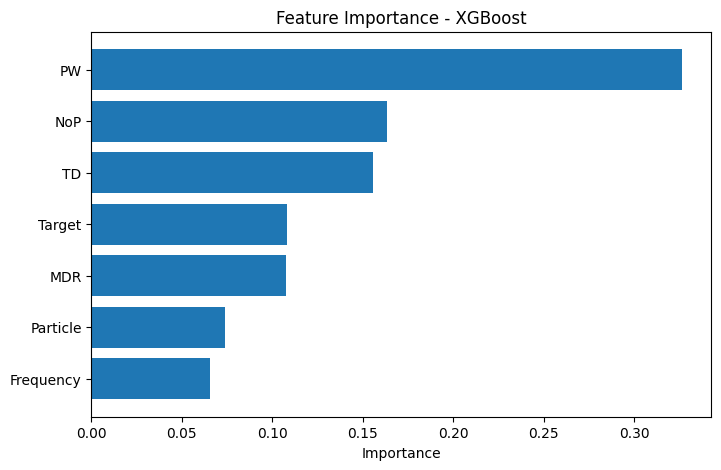

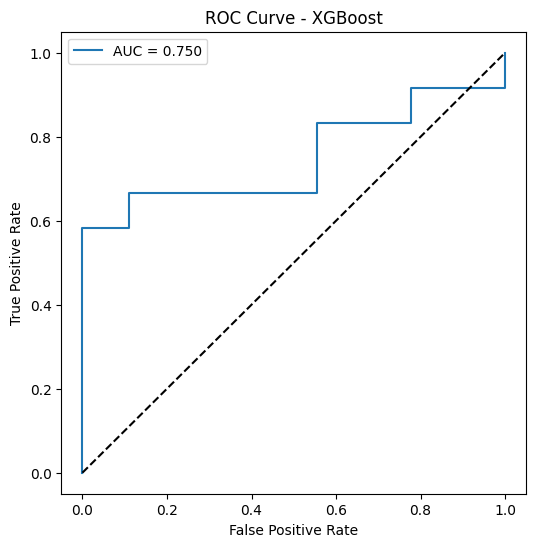

In [13]:
from src.models.evaluation import get_feature_importance
from src.visualization.plots import plot_feature_importance, plot_roc_curve

feature_importance_xgb = get_feature_importance(model_xgb, features)
plot_feature_importance(feature_importance_xgb, "XGBoost")
plot_roc_curve(model_xgb, X_val, y_val, "XGBoost")

In [14]:
from src.models.evaluation import cross_validate_model
cross_validate_model(model_xgb, X_train, y_train)

{'f1_scores': array([0.94339623, 0.90196078, 0.98113208, 0.92592593, 0.8       ]),
 'accuracy_scores': array([0.94230769, 0.90196078, 0.98039216, 0.92156863, 0.80392157]),
 'f1_mean': np.float64(0.9104830024252889),
 'f1_std': np.float64(0.06097897629251239),
 'acc_mean': np.float64(0.9100301659125188),
 'acc_std': np.float64(0.05907611008273486)}

In [17]:
len(features)

7

In [20]:
from src.models.neural_network import build_mlp
model_nn = build_mlp(input_dim=X_train.shape[1])

In [24]:
from src.models.evaluation import predict_classes
#evaluate_keras(model_nn, X_val, y_val)

ImportError: cannot import name 'predict_classes' from 'src.models.evaluation' (c:\Users\silvi\Desktop\prova\src\models\evaluation.py)